<a href="https://colab.research.google.com/github/oxedanda/pml_final_project/blob/main/notebooks/03_forecast_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecast simulator: historical baseline + experimental future forecast

This notebook consolidates the former simulator notebooks into one clearer workflow.

It has two distinct evaluation blocks:

1. **Fixed future test (2023-2025):** models are selected on rolling validation from 2018-2022 and then tested on the untouched years 2023-2025. This is the strict baseline comparison.
2. **One-step-ahead test (2023-2025):** each campaign can use lagged production from the immediately previous campaign. This is closer to an operational next-campaign forecast.

The final section uses the selected lagged model to produce an experimental 2026/27 forecast and a vineyard-area scenario simulator.

In [8]:
# Colab/local setup
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/oxedanda/pml_final_project.git"
REPO_DIR = Path("/content/pml_final_project")

if "google.colab" in sys.modules:
    if not (REPO_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=False)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=False)
else:
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        os.chdir(cwd.parent)

ROOT = Path.cwd()
print(f"Working directory: {ROOT}")

Working directory: /content/pml_final_project


In [9]:
import pandas as pd
from IPython.display import Image, display

from src.evaluate_models import evaluate, save_outputs as save_baseline_outputs
from src.future_forecast import (
    evaluate_forecasters,
    forecast_2026,
    load_history,
    save_outputs as save_future_outputs,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Data used by the simulator

The modelling dataset joins IVV wine production by viticultural region with vineyard area by region and campaign start year.

In [10]:
history = load_history()
print(f"Rows: {len(history):,}")
print(f"Regions: {history['region'].nunique()}")
print(f"Years: {history['year_start'].min()}-{history['year_start'].max()}")
display(history.head())

Rows: 238
Regions: 14
Years: 2009-2025


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
0,Alentejo,2009/10,2009,810338,356783,449833,995,2728,"23,490.00"
1,Alentejo,2010/11,2010,1189719,449096,725657,1387,13580,"23,784.81"
2,Alentejo,2011/12,2011,969832,413347,550665,560,5261,"23,903.93"
3,Alentejo,2012/13,2012,970124,399297,503636,152,67810,"23,438.40"
4,Alentejo,2013/14,2013,1127910,470086,633255,150,24419,"23,204.02"


## 2. Fixed future test: strict baseline comparison

This block reproduces the main project evaluation. The validation years are 2018-2022, and the final test years 2023-2025 are kept as a fixed future period. No information from 2023-2025 is used when selecting the model.

This answers the question: **how well can models trained up to 2022 predict the future block 2023-2025?**

Rolling validation, 2018-2022


,model,MAE,RMSE,R2,selected_on_validation
0,Linear regression,"58,179.96","84,156.48",0.97,True
1,Historical region mean,"58,463.99","89,738.90",0.97,False
2,Ridge (alpha=0.1),"59,694.53","85,167.32",0.97,False
3,Random forest (min_leaf=2),"62,630.30","102,684.59",0.96,False
4,Random forest (min_leaf=4),"66,161.79","107,021.37",0.95,False
5,Random forest (min_leaf=1),"66,512.25","109,582.19",0.95,False
6,Persistence (last region value),"70,220.13","115,756.31",0.94,False
7,Ridge (alpha=1),"74,867.45","100,680.58",0.96,False
8,Ridge (alpha=10),"139,381.03","171,432.47",0.88,False
9,Ridge (alpha=100),"251,104.06","283,835.28",0.66,False


Final fixed test, 2023-2025


,model,MAE,RMSE,R2,selected_on_validation
10,Persistence (last region value),"55,138.71","98,771.29",0.96,False
11,Historical region mean,"70,376.97","117,841.61",0.95,False
12,Linear regression,"78,982.39","115,420.16",0.95,True
13,Ridge (alpha=0.1),"79,057.56","116,689.60",0.95,False
14,Ridge (alpha=1),"86,592.56","128,858.96",0.93,False
15,Random forest (min_leaf=1),"102,481.91","237,582.96",0.78,False
16,Random forest (min_leaf=2),"105,211.98","238,249.28",0.78,False
17,Random forest (min_leaf=4),"108,208.67","230,972.23",0.79,False
18,Ridge (alpha=10),"123,149.68","178,162.05",0.87,False
19,Ridge (alpha=100),"224,458.01","273,972.34",0.70,False


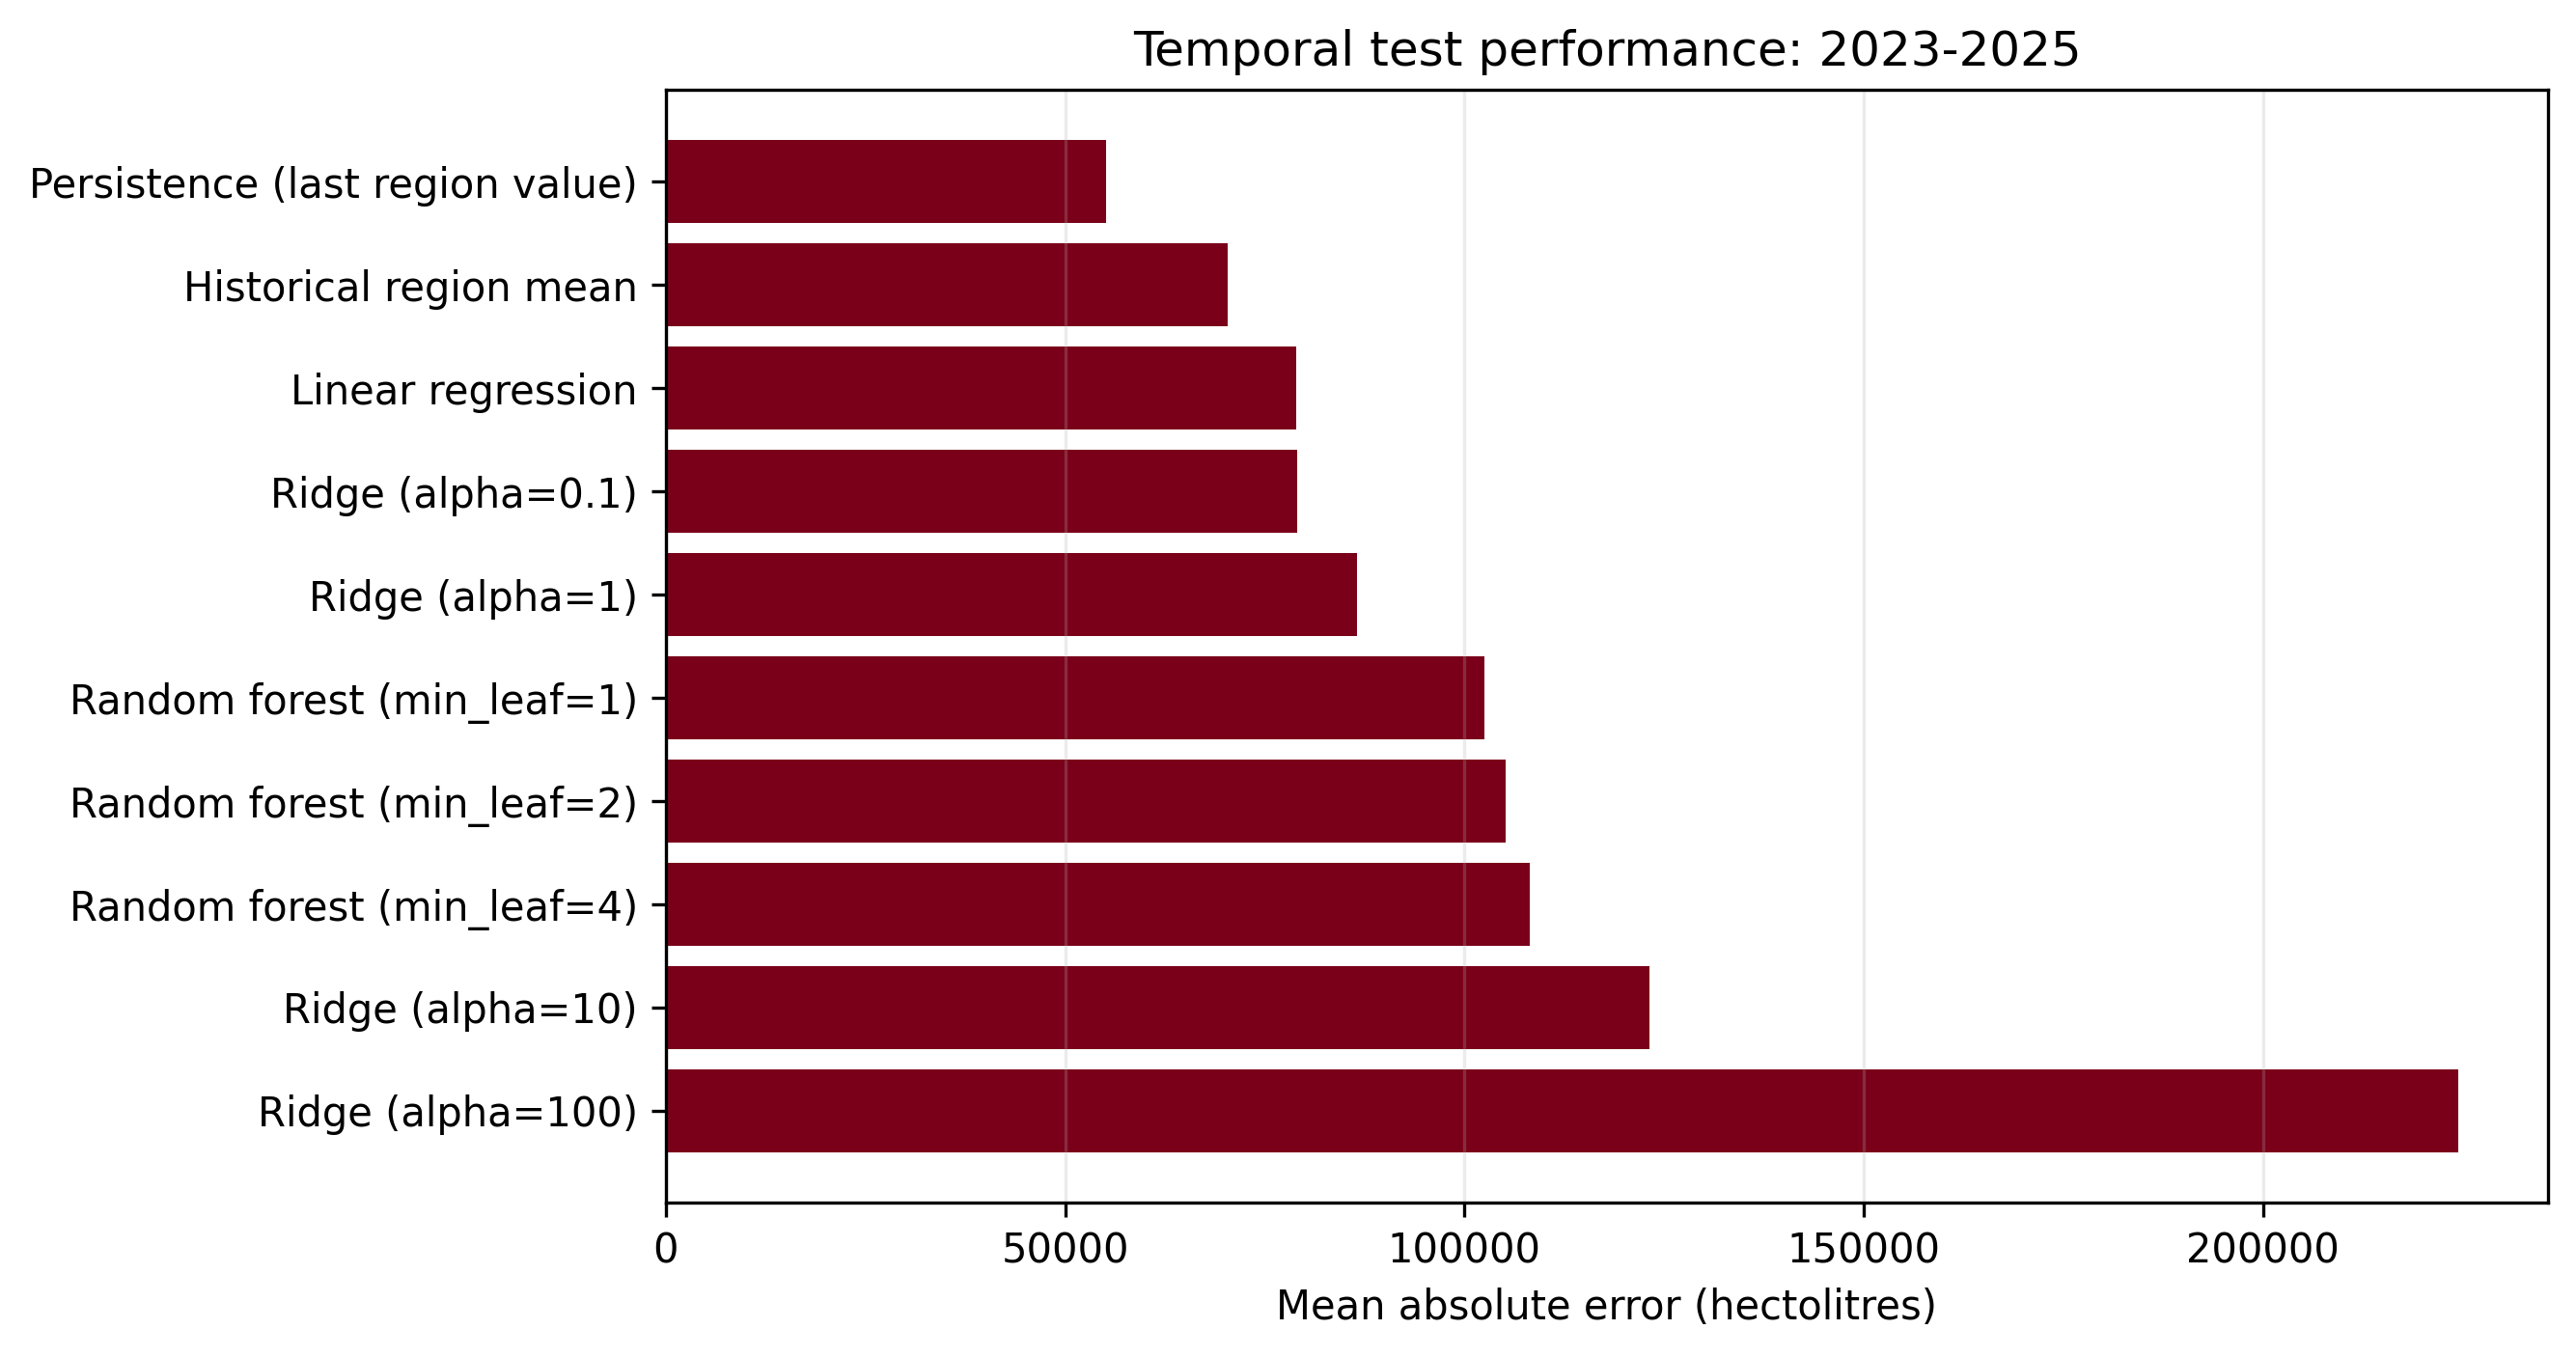

In [11]:
baseline_metrics, baseline_predictions = evaluate()
save_baseline_outputs(baseline_metrics, baseline_predictions)

baseline_validation = baseline_metrics[baseline_metrics["split"] == "rolling_validation_2018_2022"].sort_values("MAE")
baseline_test = baseline_metrics[baseline_metrics["split"] == "test_2023_2025"].sort_values("MAE")

print("Rolling validation, 2018-2022")
display(baseline_validation[["model", "MAE", "RMSE", "R2", "selected_on_validation"]])

print("Final fixed test, 2023-2025")
display(baseline_test[["model", "MAE", "RMSE", "R2", "selected_on_validation"]])

display(Image(filename="outputs/figures/model_comparison_mae.png", width=850))

**Interpretation.** The fixed test is deliberately strict. In the current results, the simple persistence baseline is stronger than the selected machine-learning model on 2023-2025. This does not mean the modelling failed; it shows that recent regional production is a very strong benchmark and that region/year/vineyard area alone do not fully capture annual shocks.

## 3. One-step-ahead extension with lagged production

This block adds lagged production features: previous campaign production, two-campaign lag, recent three-campaign mean, and recent production change. These features are shifted within each region, so the target campaign is never used as an input.

This answers a different question: **how well can we forecast the next campaign when the immediately previous campaign is already known?**

In [12]:
future_evaluation, future_forecast = save_future_outputs()

future_metrics = future_evaluation.metrics.copy()
future_validation = future_metrics[future_metrics["split"] == "rolling_validation_2018_2022"].sort_values("MAE")
one_step_test = future_metrics[future_metrics["split"] == "test_2023_2025"].sort_values("MAE")

print("Selected one-step-ahead model:", future_evaluation.selected_model)
print(f"Empirical 90% interval half-width: {future_evaluation.interval_half_width:,.0f} hl")

print("Rolling validation with lags, 2018-2022")
display(future_validation[["model", "MAE", "RMSE", "R2", "selected_on_validation"]])

print("One-step-ahead test with lags, 2023-2025")
display(one_step_test[["model", "MAE", "RMSE", "R2", "selected_on_validation"]])

Selected one-step-ahead model: Random forest with lags
Empirical 90% interval half-width: 147,976 hl
Rolling validation with lags, 2018-2022


,model,MAE,RMSE,R2,selected_on_validation
5,Random forest with lags,"52,313.73","80,663.73",0.97,True
2,Ridge with lags (alpha=0.1),"55,433.81","80,138.72",0.97,False
3,Ridge with lags (alpha=1),"56,040.41","81,925.88",0.97,False
4,Ridge with lags (alpha=10),"56,307.89","84,513.51",0.97,False
1,Linear regression with lags,"62,814.13","85,940.13",0.97,False
0,Persistence (previous campaign),"70,220.13","115,756.31",0.94,False


One-step-ahead test with lags, 2023-2025


,model,MAE,RMSE,R2,selected_on_validation
11,Random forest with lags,"59,025.88","100,229.86",0.96,True
6,Persistence (previous campaign),"69,402.57","126,722.55",0.94,False
10,Ridge with lags (alpha=10),"78,820.68","124,083.00",0.94,False
9,Ridge with lags (alpha=1),"81,914.47","128,747.56",0.93,False
8,Ridge with lags (alpha=0.1),"83,055.27","122,432.74",0.94,False
7,Linear regression with lags,"88,247.84","120,599.81",0.94,False


The one-step-ahead result should not be compared directly with the fixed future test as if they used the same information. The one-step-ahead test is allowed to use the previous campaign, so it is operationally later and usually easier.

## 4. Experimental 2026/27 forecast

The selected lagged model is refitted using the available history and then used to forecast the next campaign. The default scenario keeps the latest observed vineyard area for each region.

### Explicit prediction step

The notebook calls `forecast_2026(future_evaluation)` below. Inside that function, the selected model is refitted on the supervised historical data and the actual prediction is computed with:

```python
model.fit(supervised[FEATURES], supervised[TARGET])
prediction = model.predict(future[FEATURES])
```

The resulting table is shown as `future_forecast` and saved to `outputs/tables/forecast_2026_27.csv`.


In [13]:
future_forecast = forecast_2026(future_evaluation)
display(future_forecast)
future_forecast.to_csv("outputs/tables/forecast_2026_27.csv", index=False)

,region,year_start,vineyard_area_ha,selected_model,predicted_production_hl,lower_90_hl,upper_90_hl,region_interval_half_width_hl,historical_lower_floor_hl
0,Alentejo,2026,"25,421.93",Random forest with lags,1068766,878783,1258749,189983,243101
1,Algarve,2026,"1,201.75",Random forest with lags,18255,13883,22627,4372,3126
2,Açores,2026,"1,334.12",Random forest with lags,10151,5345,14957,4806,1081
3,Bairrada,2026,"9,180.68",Random forest with lags,188368,142118,234618,46250,45336
4,Beira Interior,2026,"11,360.82",Random forest with lags,219067,132870,305264,86197,48610
5,Douro,2026,"43,929.72",Random forest with lags,1411028,1169722,1652334,241306,335547
6,Dão,2026,"9,834.17",Random forest with lags,218304,135071,301537,83233,53523
7,Lisboa,2026,"17,819.98",Random forest with lags,1166580,991410,1341750,175170,248000
8,Madeira,2026,645.88,Random forest with lags,28790,24194,33386,4596,8093
9,P. Setúbal,2026,"7,355.33",Random forest with lags,477691,439253,516129,38438,92657


## 5. Vineyard-area scenario simulator

Changing vineyard area here creates a **scenario**, not a causal estimate. The model shows how the forecast changes if a different area is supplied, but it does not prove that changing vineyard area would directly cause that production change.

In [14]:
def simulate_region_area(region, vineyard_area_ha):
    scenario = forecast_2026(
        future_evaluation,
        area_overrides={region: float(vineyard_area_ha)},
    )
    return scenario[scenario["region"] == region]

example_region = future_forecast["region"].iloc[0]
example_area = float(
    future_forecast.loc[
        future_forecast["region"] == example_region,
        "vineyard_area_ha",
    ].iloc[0]
)

print(f"Example scenario for {example_region} with {example_area:,.2f} ha")
display(simulate_region_area(example_region, example_area))


Example scenario for Alentejo with 25,421.93 ha


,region,year_start,vineyard_area_ha,selected_model,predicted_production_hl,lower_90_hl,upper_90_hl,region_interval_half_width_hl,historical_lower_floor_hl
0,Alentejo,2026,"25,421.93",Random forest with lags,1068766,878783,1258749,189983,243101


## 6. Limits to state clearly

- The fixed future test and the one-step-ahead test answer different forecasting questions.
- The empirical 90% interval is based on observed validation errors; it is not a formal statistical confidence interval.
- Vineyard-area changes in the simulator are scenarios, not causal claims.
- Better future forecasts would require weather, drought, disease, management, or remote-sensing predictors known before harvest.